In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
# MonoBERT percentage degradations
monobert_degradation = {
    'trec_dl19': (monobert_trec_dl19 - trec_dl19) / monobert_trec_dl19,
    'trec_dl20': (monobert_trec_dl20 - trec_dl20) / monobert_trec_dl20,
    'trec_dl21': (monobert_trec_dl21 - trec_dl21) / monobert_trec_dl21,
    'trec_dl22': (monobert_trec_dl22 - trec_dl22) / monobert_trec_dl22,
    # Uncomment and add other datasets if their values are available
    'nfcorpus': (monobert_nfcorpus - nfcorpus) / monobert_nfcorpus,
    'fiqa': (monobert_fiqa - fiqa) / monobert_fiqa,
    'trec_covid': (monobert_trec_covid - trec_covid) / monobert_trec_covid,
    'robust_04': (monobert_robust_04 - robust_04) / monobert_robust_04,
    'nq': (monobert_nq - nq) / monobert_nq,
    'bioasq': (monobert_bioasq - bioasq) / monobert_bioasq,
}

monobert_ood_degradation = {
    'nfcorpus': (monobert_nfcorpus - nfcorpus) / monobert_nfcorpus,
    'fiqa': (monobert_fiqa - fiqa) / monobert_fiqa,
    'trec_covid': (monobert_trec_covid - trec_covid) / monobert_trec_covid,
    'robust_04': (monobert_robust_04 - robust_04) / monobert_robust_04,
    'nq': (monobert_nq - nq) / monobert_nq,
    'bioasq': (monobert_bioasq - bioasq) / monobert_bioasq,
}

monobert_msmarco_degradation = {
    'trec_dl19': (monobert_trec_dl19 - trec_dl19) / monobert_trec_dl19,
    'trec_dl20': (monobert_trec_dl20 - trec_dl20) / monobert_trec_dl20,
    'trec_dl21': (monobert_trec_dl21 - trec_dl21) / monobert_trec_dl21,
    'trec_dl22': (monobert_trec_dl22 - trec_dl22) / monobert_trec_dl22,
}

print("MonoBERT degradation (%):", monobert_degradation)

# Prepare a summary DataFrame for mean and variance of each degradation dictionary
degradation_dicts = {
    'monobert_degradation': monobert_degradation,
    'monobert_msmarco_degradation': monobert_msmarco_degradation,
    'monobert_ood_degradation': monobert_ood_degradation,
}

summary = []
for name, d in degradation_dicts.items():
    values = list(d.values())
    summary.append({
        'name': name,
        'mean': 1 - np.mean(values),
        'std': np.std(values)
    })

degradation_stats_df = pd.DataFrame(summary)
print(degradation_stats_df)

MiniLM degradation (%): {'trec_dl19': 0.7037037037037037, 'trec_dl20': 0.782051282051282, 'trec_dl21': 0.6883116883116883, 'trec_dl22': 0.7428571428571429, 'nfcorpus': 0.5306122448979592, 'fiqa': 0.8974358974358975, 'trec_covid': 0.4666666666666666, 'robust_04': 0.6122448979591837, 'nq': 0.8292682926829268, 'bioasq': 0.888888888888889}
MonoBERT degradation (%): {'trec_dl19': 0.6923076923076923, 'trec_dl20': 0.7792207792207791, 'trec_dl21': 0.68, 'trec_dl22': 0.7391304347826088, 'nfcorpus': 0.5306122448979592, 'fiqa': 0.9, 'trec_covid': 0.4444444444444444, 'robust_04': 0.6122448979591837, 'nq': 0.8292682926829268, 'bioasq': 0.8846153846153846}
                           name      mean       std
0            minilm_degradation  0.285796  0.137444
1          monobert_degradation  0.290816  0.141392
2   minilm_msmarcos_degradation  0.270769  0.036406
3        minilm_ood_degradation  0.295814  0.174214
4  monobert_msmarco_degradation  0.277335  0.039407
5      monobert_ood_degradation  0.29

# MSMARCOs

In [78]:
# Doc-->Doc ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/4fc54881e7897bc6cafd18529d217a0c84391d9ad275fd0424ee78fffca462c3/storage/summary_results.csv'
doc_to_doc_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_to_doc_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_to_doc_csv = doc_to_doc_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_to_doc_csv['Layer'] = range(len(doc_to_doc_csv))
doc_to_doc_csv['mean'] = 1 - doc_to_doc_csv['mean']
# Display the first few rows of the DataFrame
print(doc_to_doc_csv.head())

   Layer      mean       std
0      0  1.001720  0.007149
1      1  0.997829  0.006262
2      2  0.987703  0.003713
3      3  0.971627  0.015412
4      4  0.971231  0.014425


In [79]:
# All-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/3d78d69c45dbf175af3f11aebdb51efbbd5471efd84a854dae8ef98fa6c4b71f/storage/summary_results.csv'
all_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
all_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
all_to_cls_csv = all_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
all_to_cls_csv['Layer'] = range(len(all_to_cls_csv))
all_to_cls_csv['mean'] = 1 - all_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(all_to_cls_csv.head())

   Layer      mean       std
0      0  1.000699  0.005355
1      1  1.001506  0.004506
2      2  1.000411  0.004474
3      3  0.999754  0.004313
4      4  0.999872  0.005831


In [80]:
# Query + Doc --> CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/e339674a1490c6087cdb0c1d4b56bdefc3e6e9d2492a976380f55b81861c8955/storage/summary_results.csv'
query_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_doc_to_cls_csv = query_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_doc_to_cls_csv['Layer'] = range(len(query_doc_to_cls_csv))
query_doc_to_cls_csv['mean'] = 1 - query_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_doc_to_cls_csv.head())

   Layer      mean       std
0      0  1.000771  0.005200
1      1  1.001434  0.004986
2      2  1.001118  0.003262
3      3  1.001787  0.002148
4      4  0.999807  0.004092


In [81]:
# Doc + Query --> Doc + Query ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/75dac9b58cb79bb7c81d022872a7d18cec5f18f5bcd450cfac3d21f457d7f088/storage/summary_results.csv'
doc_query_to_doc_query_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_query_to_doc_query_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_query_to_doc_query_csv = doc_query_to_doc_query_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_query_to_doc_query_csv['Layer'] = range(len(doc_query_to_doc_query_csv))
doc_query_to_doc_query_csv['mean'] = 1 - doc_query_to_doc_query_csv['mean']
# Display the first few rows of the DataFrame
print(doc_query_to_doc_query_csv.head())

   Layer      mean       std
0      0  0.999633  0.003339
1      1  0.982679  0.007703
2      2  0.964651  0.005504
3      3  0.933515  0.020714
4      4  0.924771  0.032954


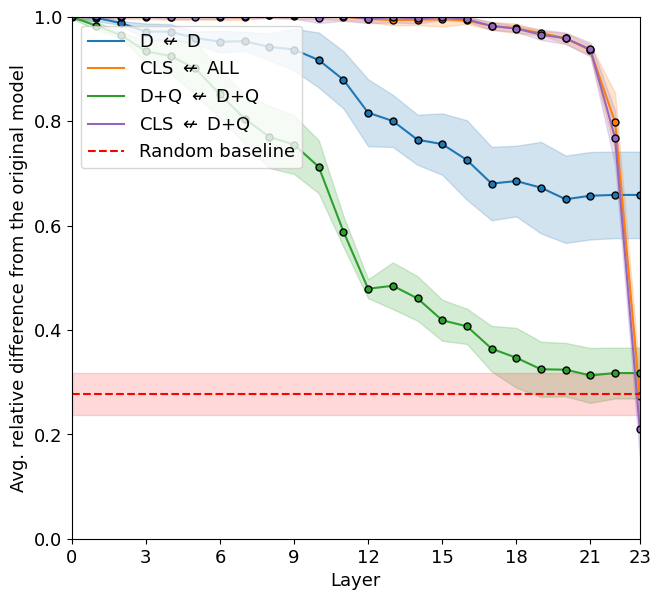

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 13})

# Seaborn color palette
palette = sns.color_palette()

# Grouped data for plotting
plot_data = [
    {
        'label': r'D $\nleftarrow$ D',
        'df': doc_to_doc_csv,
        'highlight': doc_to_doc_csv['Layer'].tolist(),
        'color': palette[0]
    },
    {
        'label': r'CLS $\nleftarrow$ ALL',
        'df': all_to_cls_csv,
        'highlight': all_to_cls_csv['Layer'].tolist(),
        'color': palette[1]
    },
    {
        'label': r'D+Q $\nleftarrow$ D+Q',
        'df': doc_query_to_doc_query_csv,
        'highlight': doc_query_to_doc_query_csv['Layer'].tolist(),
        'color': palette[2]
    },
    {
        'label': r'CLS $\nleftarrow$ D+Q',
        'df': query_doc_to_cls_csv,
        'highlight': query_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[4]
    }
]

# Function to highlight points
def highlight_points(ax, layers, data, color):
    for layer in layers:
        ax.plot(layer, data.loc[data['Layer'] == layer, 'mean'], 'o',
                markersize=5, markeredgecolor='black', markerfacecolor=color)

# Plotting loop
ax = None
for item in plot_data:
    df = item['df'].sort_values('Layer')
    x = df['Layer']
    y = df['mean']
    std = df['std'] if 'std' in df.columns else np.zeros_like(y)

    # Plot line
    ax = sns.lineplot(x=x, y=y, label=item['label'], color=item['color'], errorbar=None)

    # Add shaded std region
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=item['color'])

    # Highlight points
    highlight_points(ax, item['highlight'], df, item['color'])

# Axis and labels
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.set_xlim(left=0, right=23)
ax.set_ylim(bottom=0.0, top=1.0)
plt.xticks(ticks=np.concatenate([np.arange(0, 24, 3), [23]]))
plt.xlabel('Layer')
plt.ylabel('Avg. relative difference from the original model')

mean = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_msmarco_degradation', 'mean'].values[0]
std = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_msmarco_degradation', 'std'].values[0]
plt.plot(ax.get_xlim(), [mean, mean], color='red', linestyle='--', label='Random baseline')
plt.fill_between(ax.get_xlim(), mean - std, mean + std, color='red', alpha=0.15)

plt.legend(loc='upper left')
# Save and show
plt.subplots_adjust(left=0.1, right=0.81, top=0.97, bottom=0.1)
plt.savefig("monobert_msmarco_ablations.pdf", format="pdf")
plt.show()


# MonoBERT / OOD

In [4]:
# Doc-->Doc ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/64104fd08edf37353cf00961e3b8fc19c342f6175fdd14c5bda4737abc96f13e/storage/summary_results.csv'
doc_to_doc_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_to_doc_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_to_doc_csv = doc_to_doc_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_to_doc_csv['Layer'] = range(len(doc_to_doc_csv))
doc_to_doc_csv['mean'] = 1 - doc_to_doc_csv['mean']
# Display the first few rows of the DataFrame
print(doc_to_doc_csv.head())

   Layer      mean       std
0      0  0.997886  0.003988
1      1  0.897381  0.091594
2      2  0.901912  0.100275
3      3  0.937248  0.055465
4      4  0.941992  0.036499


In [5]:
# All-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/1e638e1c8ae1460af3dcc583aa926ad963c0b65ac70c7728837b4a26dead5548/storage/summary_results.csv'
all_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
all_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
all_to_cls_csv = all_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
all_to_cls_csv['Layer'] = range(len(all_to_cls_csv))
all_to_cls_csv['mean'] = 1 - all_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(all_to_cls_csv.head())

   Layer      mean       std
0      0  1.000924  0.003769
1      1  0.999554  0.003374
2      2  0.999858  0.003264
3      3  1.000137  0.003194
4      4  1.001777  0.004922


In [6]:
# Query + Doc --> CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/5ea2c45fb58ecd48d0055a8eb7c76d717c24105a31a8fbb9df882de2dd52fcf2/storage/summary_results.csv'
query_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_doc_to_cls_csv = query_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_doc_to_cls_csv['Layer'] = range(len(query_doc_to_cls_csv))
query_doc_to_cls_csv['mean'] = 1 - query_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_doc_to_cls_csv.head())

   Layer      mean       std
0      0  1.000454  0.003093
1      1  1.000824  0.002770
2      2  0.999928  0.001668
3      3  1.000941  0.001124
4      4  1.001562  0.002058


In [7]:
# Doc + Query --> Doc + Query ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/d2fc93ad5ff6658113a01eb8e80429ac97ea514477bf36ad7a38d7bae8ac9303/storage/summary_results.csv'
doc_query_to_doc_query_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_query_to_doc_query_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_query_to_doc_query_csv = doc_query_to_doc_query_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_query_to_doc_query_csv['Layer'] = range(len(doc_query_to_doc_query_csv))
doc_query_to_doc_query_csv['mean'] = 1 - doc_query_to_doc_query_csv['mean']
# Display the first few rows of the DataFrame
print(doc_query_to_doc_query_csv.head())

   Layer      mean       std
0      0  0.995098  0.007158
1      1  0.823532  0.119538
2      2  0.803974  0.109934
3      3  0.884633  0.051137
4      4  0.881177  0.026910


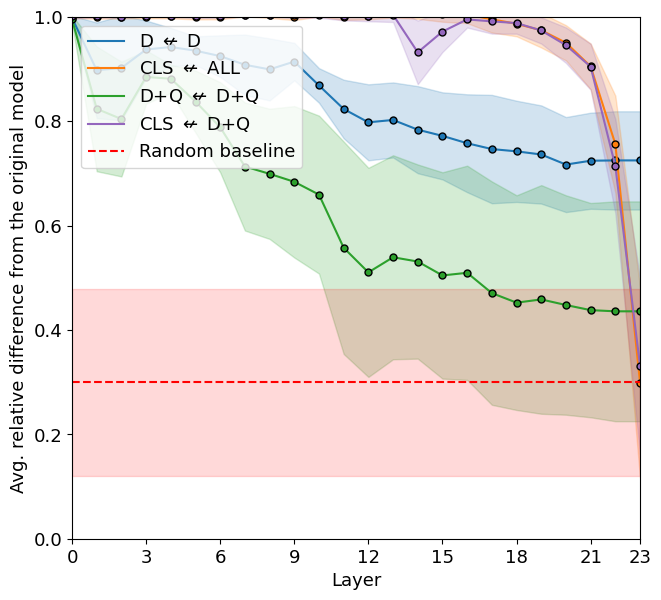

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 13})

# Seaborn color palette
palette = sns.color_palette()

# Grouped data for plotting
plot_data = [
    {
        'label': r'D $\nleftarrow$ D',
        'df': doc_to_doc_csv,
        'highlight': doc_to_doc_csv['Layer'].tolist(),
        'color': palette[0]
    },
    {
        'label': r'CLS $\nleftarrow$ ALL',
        'df': all_to_cls_csv,
        'highlight': all_to_cls_csv['Layer'].tolist(),
        'color': palette[1]
    },
    {
        'label': r'D+Q $\nleftarrow$ D+Q',
        'df': doc_query_to_doc_query_csv,
        'highlight': doc_query_to_doc_query_csv['Layer'].tolist(),
        'color': palette[2]
    },
    {
        'label': r'CLS $\nleftarrow$ D+Q',
        'df': query_doc_to_cls_csv,
        'highlight': query_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[4]
    }
]

# Function to highlight points
def highlight_points(ax, layers, data, color):
    for layer in layers:
        ax.plot(layer, data.loc[data['Layer'] == layer, 'mean'], 'o',
                markersize=5, markeredgecolor='black', markerfacecolor=color)

# Plotting loop
ax = None
for item in plot_data:
    df = item['df'].sort_values('Layer')
    x = df['Layer']
    y = df['mean']
    std = df['std'] if 'std' in df.columns else np.zeros_like(y)

    # Plot line
    ax = sns.lineplot(x=x, y=y, label=item['label'], color=item['color'], errorbar=None)

    # Add shaded std region
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=item['color'])

    # Highlight points
    highlight_points(ax, item['highlight'], df, item['color'])

# Axis and labels
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.set_xlim(left=0, right=23)
ax.set_ylim(bottom=0.0, top=1.0)
plt.xticks(ticks=np.concatenate([np.arange(0, 24, 3), [23]]))
plt.xlabel('Layer')
plt.ylabel('Avg. relative difference from the original model')

mean = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_ood_degradation', 'mean'].values[0]
std = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_ood_degradation', 'std'].values[0]
plt.plot(ax.get_xlim(), [mean, mean], color='red', linestyle='--', label='Random baseline')
plt.fill_between(ax.get_xlim(), mean - std, mean + std, color='red', alpha=0.15)

plt.legend(loc='upper left')
# Save and show
plt.subplots_adjust(left=0.1, right=0.81, top=0.97, bottom=0.1)
plt.savefig("monobert_ood_ablations.pdf", format="pdf")
plt.show()


# MonoBERT / ALL

In [12]:
# Doc-->Doc ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/120355d233e8d8ba3423fd022b214e286bbe3a16f30b7bf42cd1165f270f4402/storage/summary_results.csv'
doc_to_doc_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_to_doc_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_to_doc_csv = doc_to_doc_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_to_doc_csv['Layer'] = range(len(doc_to_doc_csv))
doc_to_doc_csv['mean'] = 1 - doc_to_doc_csv['mean']
# Display the first few rows of the DataFrame
print(doc_to_doc_csv.head())

   Layer      mean       std
0      0  0.999419  0.005790
1      1  0.937560  0.086434
2      2  0.936228  0.088345
3      3  0.951000  0.047165
4      4  0.953688  0.032980


In [13]:
# All-->CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/901660c116dc3b219b0a3aa48388206142f23cd74868ac7dc96a65b778dfc082/storage/summary_results.csv'
all_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
all_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
all_to_cls_csv = all_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
all_to_cls_csv['Layer'] = range(len(all_to_cls_csv))
all_to_cls_csv['mean'] = 1 - all_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(all_to_cls_csv.head())

   Layer      mean       std
0      0  1.000834  0.004473
1      1  1.000335  0.003983
2      2  1.000079  0.003804
3      3  0.999984  0.003688
4      4  1.001015  0.005386


In [14]:
# Query + Doc --> CLS ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/5fe6dd1c627c349e3a85ef8e48b3a50ed259b46594b51934f5a1a7b1239e7cfd/storage/summary_results.csv'
query_doc_to_cls_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
query_doc_to_cls_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
query_doc_to_cls_csv = query_doc_to_cls_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
query_doc_to_cls_csv['Layer'] = range(len(query_doc_to_cls_csv))
query_doc_to_cls_csv['mean'] = 1 - query_doc_to_cls_csv['mean']
# Display the first few rows of the DataFrame
print(query_doc_to_cls_csv.head())

   Layer      mean       std
0      0  1.000581  0.004072
1      1  1.001068  0.003826
2      2  1.000404  0.002503
3      3  1.001279  0.001666
4      4  1.000860  0.003159


In [15]:
# Doc + Query --> Doc + Query ablation
csv_file_path = '/home/vast/target_dir/relevance-integrations/jobs/src.ablations.ablation_study.summaryablationstudies/32e394110ea0e6077c1116993076a46e378ec8697b7231beff31be1a7801fb04/storage/summary_results.csv'
doc_query_to_doc_query_csv = pd.read_csv(csv_file_path)

# Rename the first column to "Layer"
doc_query_to_doc_query_csv.rename(columns={'Unnamed: 0': 'Layer'}, inplace=True)

# Drop the first row
doc_query_to_doc_query_csv = doc_query_to_doc_query_csv.iloc[1:].reset_index(drop=True)

# Change the content of the first column to be layer numbers between 0 and 24
doc_query_to_doc_query_csv['Layer'] = range(len(doc_query_to_doc_query_csv))
doc_query_to_doc_query_csv['mean'] = 1 - doc_query_to_doc_query_csv['mean']
# Display the first few rows of the DataFrame
print(doc_query_to_doc_query_csv.head())

   Layer      mean       std
0      0  0.996912  0.006335
1      1  0.887191  0.121145
2      2  0.868244  0.116015
3      3  0.904186  0.048105
4      4  0.898614  0.036400


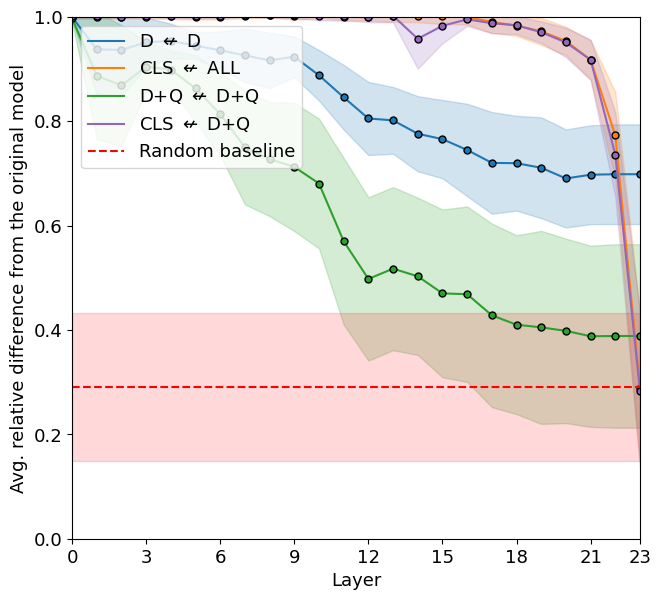

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 13})

# Seaborn color palette
palette = sns.color_palette()

# Grouped data for plotting
plot_data = [
    {
        'label': r'D $\nleftarrow$ D',
        'df': doc_to_doc_csv,
        'highlight': doc_to_doc_csv['Layer'].tolist(),
        'color': palette[0]
    },
    {
        'label': r'CLS $\nleftarrow$ ALL',
        'df': all_to_cls_csv,
        'highlight': all_to_cls_csv['Layer'].tolist(),
        'color': palette[1]
    },
    {
        'label': r'D+Q $\nleftarrow$ D+Q',
        'df': doc_query_to_doc_query_csv,
        'highlight': doc_query_to_doc_query_csv['Layer'].tolist(),
        'color': palette[2]
    },
    {
        'label': r'CLS $\nleftarrow$ D+Q',
        'df': query_doc_to_cls_csv,
        'highlight': query_doc_to_cls_csv['Layer'].tolist(),
        'color': palette[4]
    }
]

# Function to highlight points
def highlight_points(ax, layers, data, color):
    for layer in layers:
        ax.plot(layer, data.loc[data['Layer'] == layer, 'mean'], 'o',
                markersize=5, markeredgecolor='black', markerfacecolor=color)

# Plotting loop
ax = None
for item in plot_data:
    df = item['df'].sort_values('Layer')
    x = df['Layer']
    y = df['mean']
    std = df['std'] if 'std' in df.columns else np.zeros_like(y)

    # Plot line
    ax = sns.lineplot(x=x, y=y, label=item['label'], color=item['color'], errorbar=None)

    # Add shaded std region
    plt.fill_between(x, y - std, y + std, alpha=0.2, color=item['color'])

    # Highlight points
    highlight_points(ax, item['highlight'], df, item['color'])

# Axis and labels
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0.0))
ax.set_xlim(left=0, right=23)
ax.set_ylim(bottom=0.0, top=1.0)
plt.xticks(ticks=np.concatenate([np.arange(0, 24, 3), [23]]))
plt.xlabel('Layer')
plt.ylabel('Avg. relative difference from the original model')

mean = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_degradation', 'mean'].values[0]
std = degradation_stats_df.loc[degradation_stats_df['name'] == 'monobert_degradation', 'std'].values[0]
plt.plot(ax.get_xlim(), [mean, mean], color='red', linestyle='--', label='Random baseline')
plt.fill_between(ax.get_xlim(), mean - std, mean + std, color='red', alpha=0.15)

plt.legend(loc='upper left')
# Save and show
plt.subplots_adjust(left=0.1, right=0.81, top=0.97, bottom=0.1)
plt.savefig("monobert_all_ablations.pdf", format="pdf")
plt.show()
